In [ ]:
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d abdelazizsami/bank-marketing -p /content --unzip

Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/abdelazizsami/bank-marketing
License(s): apache-2.0
100% 578k/578k [00:00<00:00, 93.9MB/s]



# Analysis of Bank Marketing Campaign Success

## Annotation

This project analyzes the bank's marketing data set, which contains information about customers, their personal characteristics, previous contacts with the bank, and the results of a marketing campaign. The main goal of the project is to clear data, calculate statistics, create visualizations such as graphs or histograms, transform multiple columns, and test hypotheses about customer behavior and campaign success to understand what factors are associated with a successful term deposit subscription.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
df = pd.read_csv('/content/bank.csv', sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


The work was divided between Elizaveta Kadurina and Zlata Baltser. Zlata was responsible for dataset loading, data cleanup and visualizations. Elizaveta worked on dataset description, descriptive statistics and data transformation. We contributed to writing explanations and the final discussion. Additionally, we checked the hypotheses together.

## Dataset description

The dataset used in this project is the Bank Marketing dataset. It contains information about clients of a bank and results of a direct marketing campaign. The target column is `y`, which shows whether the client subscribed to a term deposit. The dataset includes both numerical and categorical variables. Numerical variables include age, balance, day, duration, campaign, pdays, and previous. Categorical variables include job, marital status, education, default, housing loan, personal loan, contact type, month, previous outcome, and the target variable. A basic check of the dataset shows the number of rows and columns, data types, missing values, and general descriptive statistics for numeric variables.

The dataset was downloaded from Kaggle: https://www.kaggle.com/datasets/abdelazizsami/bank-marketing/data

In this project, the file `bank.csv` is used. It contains 4521 rows and 17 columns.

In [ ]:
print("Number of rows and columns:")
print(df.shape)

df.head()

Number of rows and columns:
(4521, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [ ]:
df.isna().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [ ]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


## Descriptive statistics

We have calculated descriptive statistics for numeric columns. We focus on the mean, median, and standard deviation. These statistics help us understand the overall distribution of customer age, account balance, call duration, number of contacts during the campaign, and contacts in previous campaigns.

In [ ]:
num_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

df[num_cols].agg(['mean', 'median', 'std'])

,age,balance,day,duration,campaign,pdays,previous
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
median,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562


## Data cleanup

Before creating visualizations and testing hypotheses, we need to check the dataset for missing values, duplicate rows, and incorrect data types.

In [ ]:
print("Missing values:")
print(df.isna().sum())

print("\nDuplicated rows:")
print(df.duplicated().sum())

Missing values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Duplicated rows:
0


In [ ]:
df = df.drop_duplicates()

print("Shape after removing duplicates:")
print(df.shape)

Shape after removing duplicates:
(4521, 17)


In [ ]:
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']

for col in cat_cols:
    print(col)
    print(df[col].value_counts())
    print()

job
job
management       969
blue-collar      946
technician       768
admin.           478
services         417
retired          230
self-employed    183
entrepreneur     168
unemployed       128
housemaid        112
student           84
unknown           38
Name: count, dtype: int64

marital
marital
married     2797
single      1196
divorced     528
Name: count, dtype: int64

education
education
secondary    2306
tertiary     1350
primary       678
unknown       187
Name: count, dtype: int64

default
default
no     4445
yes      76
Name: count, dtype: int64

housing
housing
yes    2559
no     1962
Name: count, dtype: int64

loan
loan
no     3830
yes     691
Name: count, dtype: int64

contact
contact
cellular     2896
unknown      1324
telephone     301
Name: count, dtype: int64

month
month
may    1398
jul     706
aug     633
jun     531
nov     389
apr     293
feb     222
jan     148
oct      80
sep      52
mar      49
dec      20
Name: count, dtype: int64

poutcome
poutcome
unknown

After checking the dataset, no duplicated rows were found. The dataset does not contain standard missing values such as NaN. However, some categorical columns contain the value `unknown`. These values were kept in the dataset because they represent unavailable information from the original data. The value `pdays = -1` was also kept because it means that the client was not contacted before the current campaign.

## Basic graphs

We have created graphs for numeric variables. These graphs help us understand the distribution by customer age, account balance, call duration, and number of contacts during the campaign.

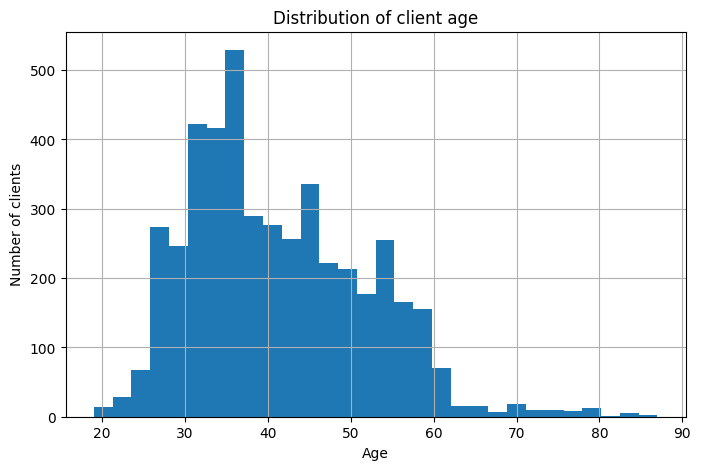

In [ ]:
plt.figure(figsize=(8, 5))
df['age'].hist(bins=30)

plt.title('Distribution of client age')
plt.xlabel('Age')
plt.ylabel('Number of clients')
plt.show()

The histogram shows the distribution of client age. Most clients are adults, while very young and very old clients appear less frequently in the dataset.

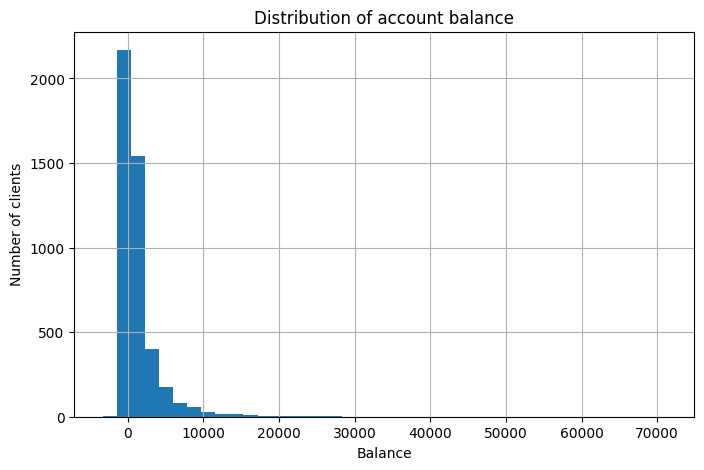

In [ ]:
plt.figure(figsize=(8, 5))
df['balance'].hist(bins=40)

plt.title('Distribution of account balance')
plt.xlabel('Balance')
plt.ylabel('Number of clients')
plt.show()

The balance distribution shows how much money is in the clients' accounts. The distribution is not quite normal, and some customers may have very high or very low balances.

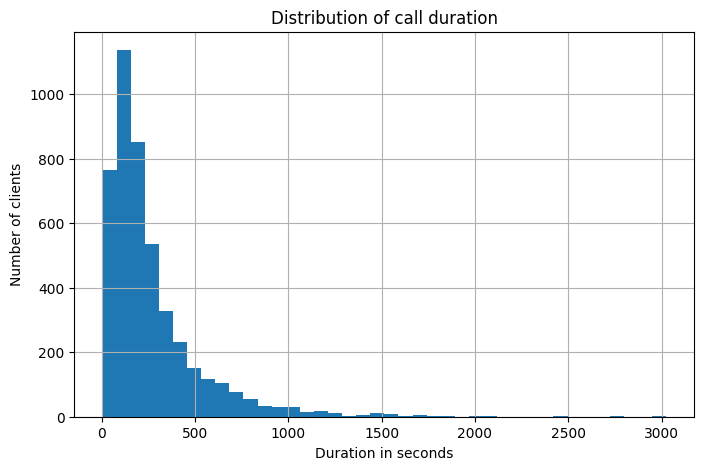

In [ ]:
plt.figure(figsize=(8, 5))
df['duration'].hist(bins=40)

plt.title('Distribution of call duration')
plt.xlabel('Duration in seconds')
plt.ylabel('Number of clients')
plt.show()

The call duration distribution shows that most calls are relatively short. However, there are also some longer calls, which may be important for campaign success.

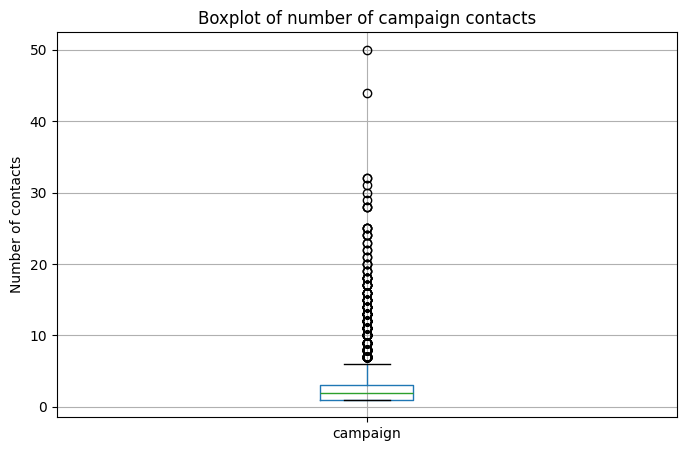

In [ ]:
plt.figure(figsize=(8, 5))
df.boxplot(column='campaign')

plt.title('Boxplot of number of campaign contacts')
plt.ylabel('Number of contacts')
plt.show()

The boxplot shows the number of contacts established during the campaign. Most of the clients have been contacted only a few times, but there are also those who have been contacted many times.

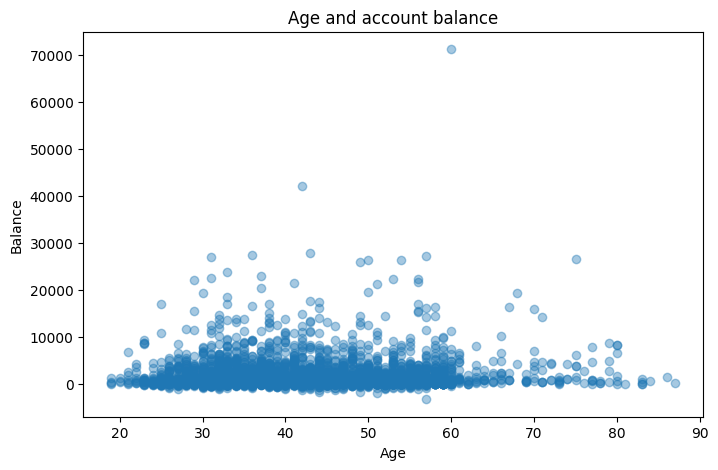

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df['age'], df['balance'], alpha=0.4)

plt.title('Age and account balance')
plt.xlabel('Age')
plt.ylabel('Balance')
plt.show()

The scatter plot compares client age and account balance. The graph helps identify clients with unusually high or low balances.

## Detailed overview

We have analyzed and compared the subscription price for different customer groups and the characteristics of the campaign.

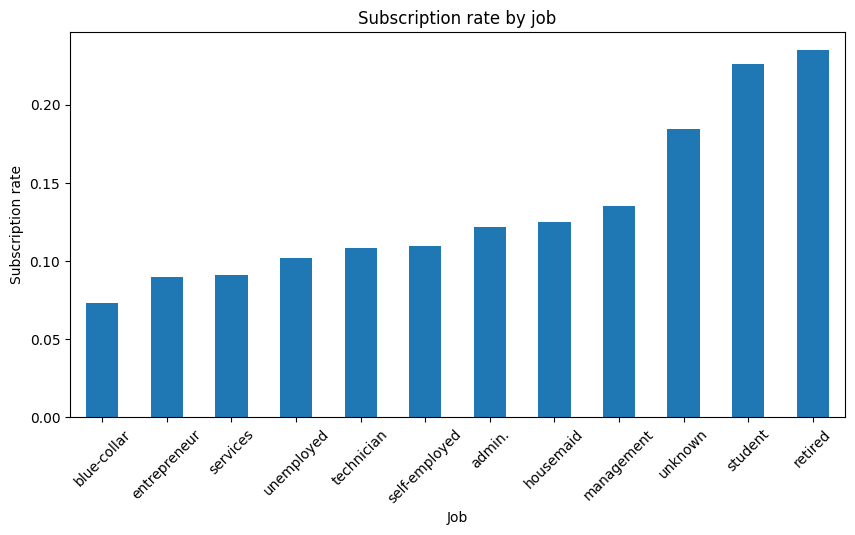

In [ ]:
job_success = df.groupby('job')['y'].apply(lambda x: (x == 'yes').mean()).sort_values()

plt.figure(figsize=(10, 5))
job_success.plot(kind='bar')

plt.title('Subscription rate by job')
plt.xlabel('Job')
plt.ylabel('Subscription rate')
plt.xticks(rotation=45)
plt.show()

The graph shows that subscription rates differ across job categories. Some job groups have a higher proportion of clients who subscribed to a term deposit, while others have lower success rates.

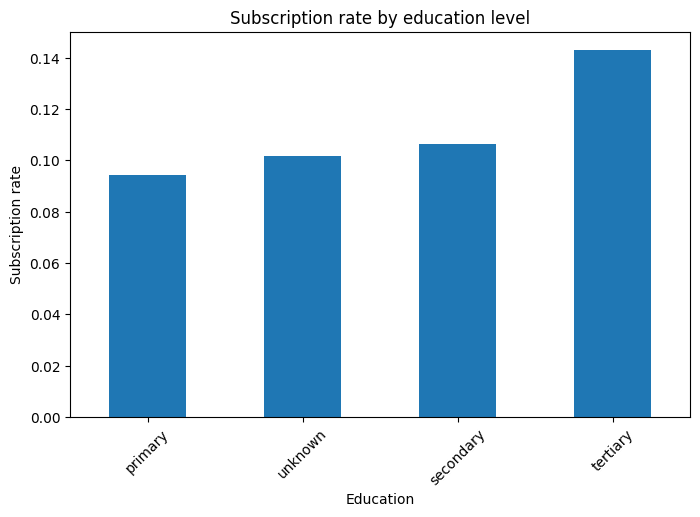

In [ ]:
education_success = df.groupby('education')['y'].apply(lambda x: (x == 'yes').mean()).sort_values()

plt.figure(figsize=(8, 5))
education_success.plot(kind='bar')

plt.title('Subscription rate by education level')
plt.xlabel('Education')
plt.ylabel('Subscription rate')
plt.xticks(rotation=45)
plt.show()

This graph compares subscription rates for different education levels. It helps us understand whether education level may be related to the probability of subscribing to a term deposit.

<Figure size 800x500 with 0 Axes>

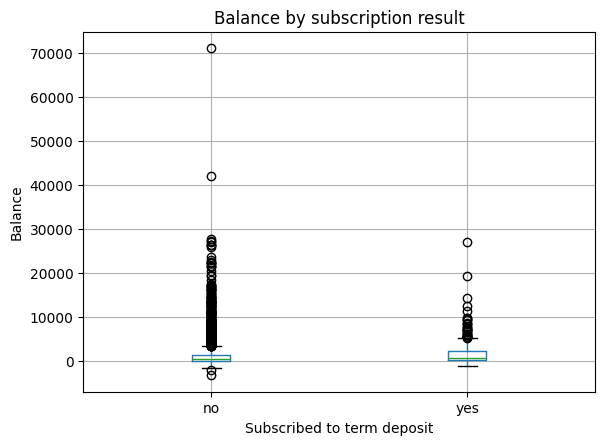

In [ ]:
plt.figure(figsize=(8, 5))
df.boxplot(column='balance', by='y')

plt.title('Balance by subscription result')
plt.suptitle('')
plt.xlabel('Subscribed to term deposit')
plt.ylabel('Balance')
plt.show()

The boxplot shows the distribution of account balance for clients who subscribed and did not subscribe. The rectangle represents the middle 50% of values, the line inside the rectangle represents the median, and separate points or squares represent outliers. Outliers are clients with unusually high or low balances. This helps us see whether clients with higher balances were more likely to accept the offer.

<Figure size 800x500 with 0 Axes>

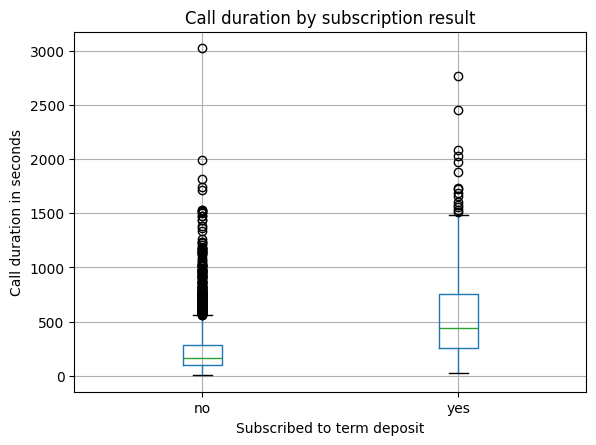

In [ ]:
plt.figure(figsize=(8, 5))
df.boxplot(column='duration', by='y')

plt.title('Call duration by subscription result')
plt.suptitle('')
plt.xlabel('Subscribed to term deposit')
plt.ylabel('Call duration in seconds')
plt.show()

The boxplot shows the relationship between call duration and subscription result. Longer calls may be associated with a higher chance of successful subscription.

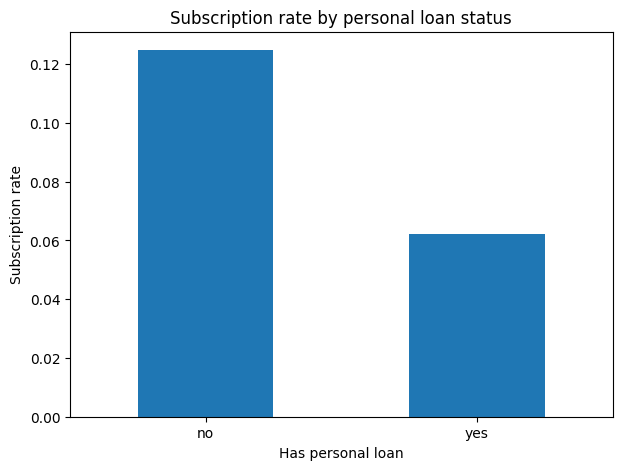

In [ ]:
loan_success = df.groupby('loan')['y'].apply(lambda x: (x == 'yes').mean())

plt.figure(figsize=(7, 5))
loan_success.plot(kind='bar')

plt.title('Subscription rate by personal loan status')
plt.xlabel('Has personal loan')
plt.ylabel('Subscription rate')
plt.xticks(rotation=0)
plt.show()

This graph compares clients with and without personal loans. It shows whether having a personal loan is related to the probability of subscribing to a term deposit.

In [ ]:
education_loan_rate = (
    df.groupby(['education', 'loan'])['y']
    .apply(lambda x: (x == 'yes').mean())
    .unstack()
)

education_loan_rate

loan,no,yes
education,,
primary,0.102740,0.042553
secondary,0.115873,0.062500
tertiary,0.153061,0.074713
unknown,0.105556,0.000000


<Figure size 800x500 with 0 Axes>

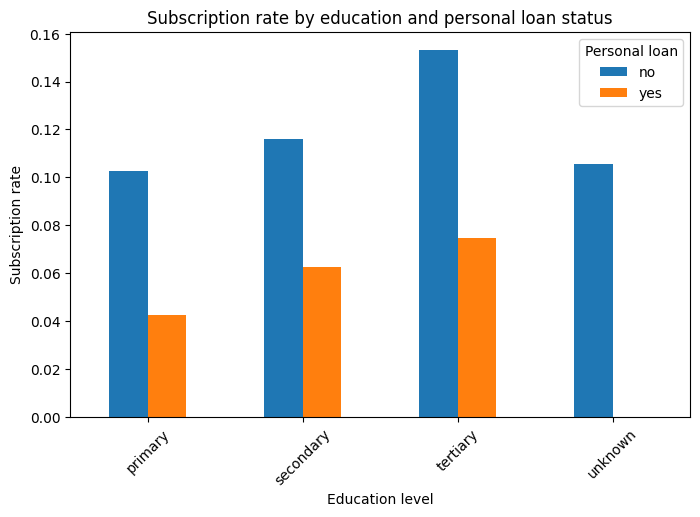

In [ ]:
plt.figure(figsize=(8, 5))

education_loan_rate.plot(kind='bar', figsize=(8, 5))

plt.title('Subscription rate by education and personal loan status')
plt.xlabel('Education level')
plt.ylabel('Subscription rate')
plt.xticks(rotation=45)
plt.legend(title='Personal loan')
plt.show()

The grouped bar chart compares subscription rates for different education levels and personal loan statuses. It shows that the probability of subscribing to a term deposit may depend on both education and whether the client has a personal loan.

In [ ]:
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

month_contact_rate = (
    df.groupby(['month', 'contact'])['y']
    .apply(lambda x: (x == 'yes').mean())
    .unstack()
    .reindex(month_order)
)

month_contact_rate

contact,cellular,telephone,unknown
month,,,
jan,0.108527,0.111111,0.000000
feb,0.180905,0.086957,NaN
mar,0.421053,0.500000,0.000000
apr,0.192029,0.176471,NaN
may,0.107750,0.081633,0.039024
jun,0.424658,0.375000,0.046667
jul,0.085069,0.098039,0.071429
aug,0.120264,0.250000,0.166667
sep,0.333333,0.666667,0.142857


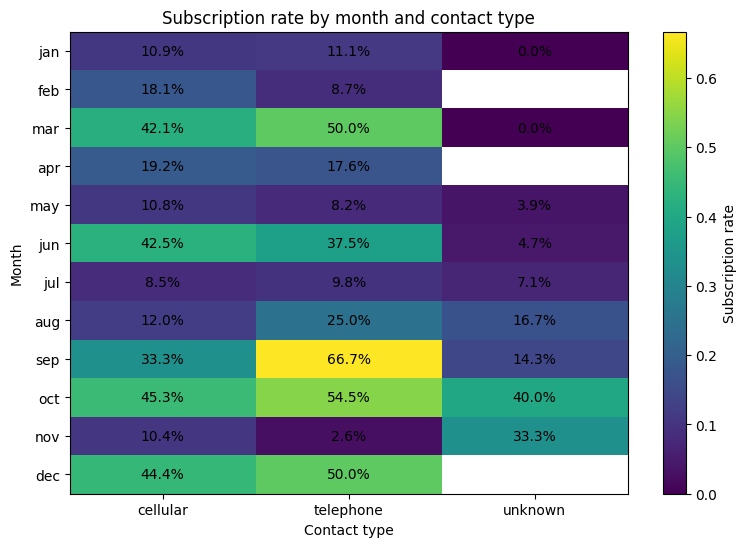

In [ ]:
plt.figure(figsize=(9, 6))

plt.imshow(month_contact_rate, aspect='auto')

plt.title('Subscription rate by month and contact type')
plt.xlabel('Contact type')
plt.ylabel('Month')

plt.xticks(range(len(month_contact_rate.columns)), month_contact_rate.columns)
plt.yticks(range(len(month_contact_rate.index)), month_contact_rate.index)

plt.colorbar(label='Subscription rate')

for i in range(len(month_contact_rate.index)):
    for j in range(len(month_contact_rate.columns)):
        value = month_contact_rate.iloc[i, j]
        if pd.notna(value):
            plt.text(j, i, f'{value:.1%}', ha='center', va='center')

plt.show()

The heatmap shows subscription rates for different combinations of month and contact type. Darker or lighter cells represent different levels of campaign success.it compares two categorical variables at the same time: the month of the campaign and the communication method. It helps identify combinations where the subscription rate was higher or lower.

In [ ]:
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

month_contact_rate = (
    df.groupby(['month', 'contact'])['y']
    .apply(lambda x: (x == 'yes').mean())
    .unstack()
    .reindex(month_order)
)

month_contact_rate

contact,cellular,telephone,unknown
month,,,
jan,0.108527,0.111111,0.000000
feb,0.180905,0.086957,NaN
mar,0.421053,0.500000,0.000000
apr,0.192029,0.176471,NaN
may,0.107750,0.081633,0.039024
jun,0.424658,0.375000,0.046667
jul,0.085069,0.098039,0.071429
aug,0.120264,0.250000,0.166667
sep,0.333333,0.666667,0.142857


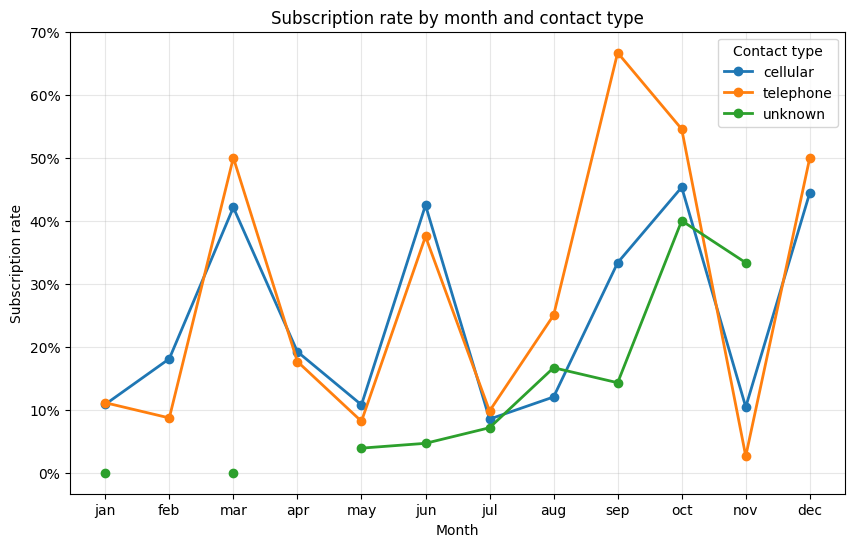

In [ ]:
from matplotlib.ticker import PercentFormatter

plt.figure(figsize=(10, 6))

for contact_type in month_contact_rate.columns:
    plt.plot(
        month_contact_rate.index,
        month_contact_rate[contact_type],
        marker='o',
        linewidth=2,
        label=contact_type
    )

plt.title('Subscription rate by month and contact type')
plt.xlabel('Month')
plt.ylabel('Subscription rate')
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.grid(True, alpha=0.3)
plt.legend(title='Contact type')
plt.show()

The line plot compares subscription rates across different months and contact types. It shows that campaign success is not the same throughout the year and may also depend on the method of communication.it analyzes changes over time and compares several contact types at once.

## Data transformation

We have created new columns based on existing data. These columns make it easier to analyze the success of the marketing campaign and compare different groups of clients.

In [ ]:
df['successful_subscription'] = df['y'].map({'yes': 1, 'no': 0})

def age_group(age):
    if age < 30:
        return 'young'
    elif age < 60:
        return 'adult'
    else:
        return 'senior'

df['age_group'] = df['age'].apply(age_group)
df['was_previously_contacted'] = df['pdays'].apply(lambda x: 0 if x == -1 else 1)
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,successful_subscription,age_group,was_previously_contacted
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no,0,adult,0
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no,0,adult,1
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no,0,adult,1
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no,0,adult,0
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no,0,adult,0


Three new columns were created. The column `successful_subscription` converts the target variable into numerical form, where 1 means success and 0 means failure. The column `age_group` divides clients into young, adult, and senior groups. The column `was_previously_contacted` shows whether the client had been contacted before the current campaign.

## Hypothesis checking

We check two hypotheses about factors that may be related to successful subscription to a term deposit. We use subscription rates, correlation, p-values, and visualizations.

In [ ]:
from scipy.stats import spearmanr, pearsonr, chi2_contingency

In [ ]:
if 'successful_subscription' not in df.columns:
    df['successful_subscription'] = df['y'].map({'yes': 1, 'no': 0})

df[['y', 'successful_subscription']].head()

,y,successful_subscription
0,no,0
1,no,0
2,no,0
3,no,0
4,no,0


### Hypothesis 1

What is the correlation between previous client contact and the likelihood of subscribing to a term deposit? Do clients with different numbers of prior contacts receive fair treatment, meaning a proportional increase in subscription probability when they are contacted again?

In [ ]:
h1_corr, h1_p = spearmanr(df['previous'], df['successful_subscription'])

print("Spearman correlation between number of previous contacts and subscription:")
print(round(h1_corr, 3))

print("p-value:")
print(h1_p)

Spearman correlation between number of previous contacts and subscription:
0.165
p-value:
4.5273749269053314e-29


In [ ]:
def previous_group(x):
    if x >= 5:
        return '5+'
    else:
        return str(x)

df['previous_group'] = df['previous'].apply(previous_group)

previous_order = ['0', '1', '2', '3', '4', '5+']

previous_result = (
    df.groupby('previous_group')
    .agg(
        number_of_clients=('successful_subscription', 'count'),
        subscription_rate=('successful_subscription', 'mean')
    )
    .reindex(previous_order)
)

previous_result['subscription_rate_percent'] = previous_result['subscription_rate'] * 100
previous_result['increase_from_previous_group'] = previous_result['subscription_rate'].diff()

previous_result

,number_of_clients,subscription_rate,subscription_rate_percent,increase_from_previous_group
previous_group,,,,
0,3705,0.090958,9.095816,NaN
1,286,0.178322,17.832168,0.087364
2,193,0.259067,25.906736,0.080746
3,113,0.194690,19.469027,-0.064377
4,78,0.320513,32.051282,0.125823
5+,146,0.246575,24.657534,-0.073937


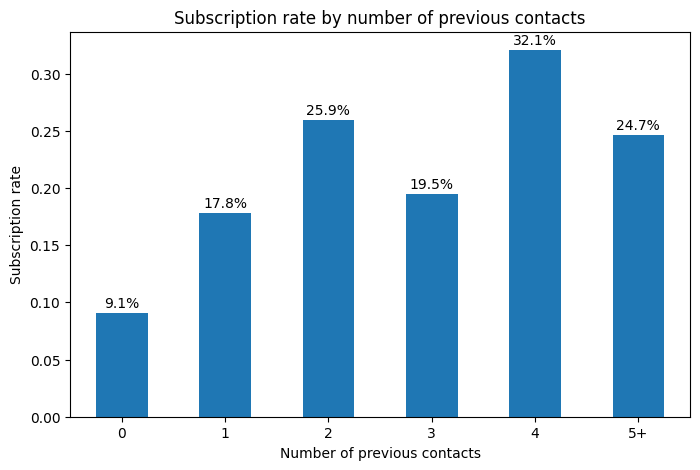

In [ ]:
plt.figure(figsize=(8, 5))

previous_result['subscription_rate'].plot(kind='bar')

plt.title('Subscription rate by number of previous contacts')
plt.xlabel('Number of previous contacts')
plt.ylabel('Subscription rate')
plt.xticks(rotation=0)

for i, value in enumerate(previous_result['subscription_rate']):
    if pd.notna(value):
        plt.text(i, value + 0.005, f'{value:.1%}', ha='center')

plt.show()

The Spearman correlation shows the relationship between the number of previous contacts and the probability of subscribing to a term deposit. The p-value is below 0.05, which means that this relationship is statistically significant.

The table and bar chart show that clients with previous contacts usually have a higher subscription rate than clients with zero previous contacts. However, the increase is not perfectly proportional for every number of previous contacts. Therefore, the hypothesis is partially supported: previous contacts are related to subscription probability, but the data does not show a perfectly linear or proportional increase.

### Hypothesis 2

What is the correlation between having a personal loan and the likelihood of subscribing to a term deposit? Do clients without a personal loan receive a fair advantage in subscription probability compared to those with a personal loan, given their different financial situations?

In [ ]:
df['loan_binary'] = df['loan'].map({'no': 0, 'yes': 1})

h2_corr, h2_p = pearsonr(df['loan_binary'], df['successful_subscription'])

print("Correlation between having a personal loan and subscription:")
print(round(h2_corr, 3))

print("p-value:")
print(h2_p)

Correlation between having a personal loan and subscription:
-0.071
p-value:
2.0742845898962986e-06


In [ ]:
loan_result = (
    df.groupby('loan')
    .agg(
        number_of_clients=('successful_subscription', 'count'),
        subscription_rate=('successful_subscription', 'mean')
    )
)

loan_result['subscription_rate_percent'] = loan_result['subscription_rate'] * 100

difference = loan_result.loc['no', 'subscription_rate'] - loan_result.loc['yes', 'subscription_rate']

print("Difference between clients without and with personal loans:")
print(round(difference, 3))

loan_result

Difference between clients without and with personal loans:
0.063


,number_of_clients,subscription_rate,subscription_rate_percent
loan,,,
no,3830,0.124804,12.480418
yes,691,0.062229,6.222865


In [ ]:
loan_table = pd.crosstab(df['loan'], df['y'])
loan_table

y,no,yes
loan,,
no,3352,478
yes,648,43


In [ ]:
chi2, chi2_p, dof, expected = chi2_contingency(loan_table)

print("Chi-square statistic:")
print(round(chi2, 3))

print("p-value:")
print(chi2_p)

Chi-square statistic:
21.872
p-value:
2.9148288298428256e-06


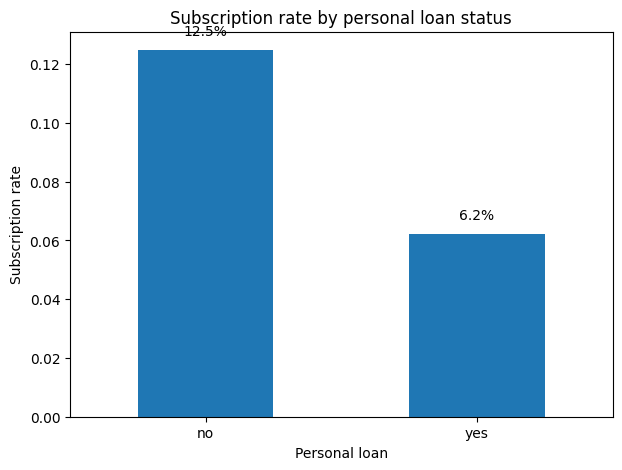

In [ ]:
plt.figure(figsize=(7, 5))

loan_result['subscription_rate'].plot(kind='bar')

plt.title('Subscription rate by personal loan status')
plt.xlabel('Personal loan')
plt.ylabel('Subscription rate')
plt.xticks(rotation=0)

for i, value in enumerate(loan_result['subscription_rate']):
    plt.text(i, value + 0.005, f'{value:.1%}', ha='center')

plt.show()

The correlation between having a personal loan and subscribing to a term deposit is negative. This means that clients with personal loans are less likely to subscribe than clients without personal loans.

The grouped results show that clients without personal loans have a higher subscription rate than clients with personal loans. The chi-square p-value is below 0.05, so the relationship between personal loan status and subscription result is statistically significant.

Therefore, the hypothesis is supported: clients without personal loans have an observed advantage in subscription probability.

## Conclusion

This project analyzed the Bank Marketing dataset to understand which factors are related to successful subscription to a term deposit. The dataset contained both numerical and categorical variables, including client age, job, education, balance, loans, previous contacts, call duration, and campaign result.

The initial data inspection showed that the dataset did not contain standard missing values or duplicated rows. However, some categorical columns contained the value `unknown`, which was kept because it represents unavailable information. The value `pdays = -1` was also kept because it has a specific meaning: the client had not been contacted before the current campaign.

The visualizations showed that subscription rates differ between different client groups. Job, education, loan status, previous contact, and call duration may be related to campaign success. The hypothesis checking section showed which factors were more strongly associated with successful subscription.

Overall, the analysis suggests that campaign success is not random. Client characteristics and campaign-related variables can help explain why some clients subscribed to a term deposit while others did not.